In [2]:
!pip install -q transformers datasets evaluate accelerate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.7 MB/s eta 0:00:00


In [3]:
import torch
import json
import os
import random
import numpy as np

from google.colab import drive

drive.mount("/content/drive")

PROJECT_DIR = "/content/drive/MyDrive/ShweMyanmar"

DATA_DIR = f"{PROJECT_DIR}/data"
MODEL_DIR = f"{PROJECT_DIR}/models"
RESULTS_DIR = f"{PROJECT_DIR}/results"

TRAIN_PATH = f"{DATA_DIR}/train.jsonl"
VAL_PATH = f"{DATA_DIR}/validation.jsonl"
TEST_PATH = f"{DATA_DIR}/test.jsonl"

POS2ID_PATH = f"{DATA_DIR}/pos2id.json"
ID2POS_PATH = f"{DATA_DIR}/id2pos.json"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Train:", TRAIN_PATH)
print("Validation:", VAL_PATH)
print("Test:", TEST_PATH)
print("Device:", "GPU" if torch.cuda.is_available() else "CPU")

Mounted at /content/drive
Train: /content/drive/MyDrive/ShweMyanmar/data/train.jsonl
Validation: /content/drive/MyDrive/ShweMyanmar/data/validation.jsonl
Test: /content/drive/MyDrive/ShweMyanmar/data/test.jsonl
Device: GPU


In [4]:
from transformers import AutoTokenizer
MODEL_NAME = "bert-base-multilingual-cased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Model:", MODEL_NAME)
print("Tokenizer loaded successfully.")

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

Model: bert-base-multilingual-cased
Tokenizer loaded successfully.


In [5]:
with open(TRAIN_PATH, "r", encoding="utf-8") as f:
    for i in range(3):
        line = f.readline()

        print(f"TRAIN LINE {i + 1}")
        print(line[:1000])
        print("-" * 80)

TRAIN LINE 1
{"id": "sent_05161", "source_text": "နေရာ/n များ/adj စွာ/part မှ/ppm ရရှိ/v|ထား/part|ချက်/part အရ/ppm ၊/punc 70/fw %/sb သော/part ကမ္ဘာ့/n|မွတ်စလင်/n များ/part သည်/ppm ဆွန်နီ/n ၊/punc 20/fw %/sb သည်/ppm ၊/punc ရှီးအတ်/n နှင့်/conj ကျန်/v 10/fw %/sb သည်/ppm အခြား/adj သော/part အမျိုးမျိုး/n ရှိ/v ကြ/part သည်/ppm အဖွဲ့/n ငယ်/adj များ/part နှင့်/conj အစ္စလာမ်/n အခွဲ/n များ/part ဖြစ်/v သည်/ppm ။/punc", "tokens": ["နေရာ", "များ", "စွာ", "မှ", "ရရှိ", "ထား", "ချက်", "အရ", "၊", "70", "%", "သော", "ကမ္ဘာ့", "မွတ်စလင်", "များ", "သည်", "ဆွန်နီ", "၊", "20", "%", "သည်", "၊", "ရှီးအတ်", "နှင့်", "ကျန်", "10", "%", "သည်", "အခြား", "သော", "အမျိုးမျိုး", "ရှိ", "ကြ", "သည်", "အဖွဲ့", "ငယ်", "များ", "နှင့်", "အစ္စလာမ်", "အခွဲ", "များ", "ဖြစ်", "သည်", "။"], "pos_tags": ["n", "adj", "part", "ppm", "v", "part", "part", "ppm", "punc", "fw", "sb", "part", "n", "n", "part", "ppm", "n", "punc", "fw", "sb", "ppm", "punc", "n", "conj", "v", "fw", "sb", "ppm", "adj", "part", "n", "v", "part", "ppm", "n"

In [6]:
def load_jsonl(path):
    data = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if line:
                data.append(json.loads(line))

    return data


train_data = load_jsonl(TRAIN_PATH)
val_data = load_jsonl(VAL_PATH)
test_data = load_jsonl(TEST_PATH)

print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))

Train: 33641
Validation: 4205
Test: 4206


In [7]:
def validate_pos_dataset(data, split_name):

    errors = []

    for i, example in enumerate(data):

        required_fields = [
            "tokens",
            "pos_tags",
            "pos_ids"
        ]

        for field in required_fields:
            if field not in example:
                errors.append(
                    (i, f"Missing field: {field}")
                )

        if not all(
            field in example
            for field in required_fields
        ):
            continue

        tokens = example["tokens"]
        tags = example["pos_tags"]
        ids = example["pos_ids"]

        if len(tokens) != len(tags):
            errors.append(
                (i, "tokens != pos_tags")
            )

        if len(tokens) != len(ids):
            errors.append(
                (i, "tokens != pos_ids")
            )

    print(f"\n{split_name}")
    print("Examples:", len(data))
    print("Errors:", len(errors))

    if errors:
        print("First 10 errors:")
        for error in errors[:10]:
            print(error)

    return errors


train_errors = validate_pos_dataset(
    train_data,
    "TRAIN"
)

val_errors = validate_pos_dataset(
    val_data,
    "VALIDATION"
)

test_errors = validate_pos_dataset(
    test_data,
    "TEST"
)


TRAIN
Examples: 33641
Errors: 0

VALIDATION
Examples: 4205
Errors: 0

TEST
Examples: 4206
Errors: 0


In [8]:
with open(
    POS2ID_PATH,
    "r",
    encoding="utf-8"
) as f:
    label2id = json.load(f)

with open(
    ID2POS_PATH,
    "r",
    encoding="utf-8"
) as f:
    loaded_id2label = json.load(f)

# JSON keys are strings, convert them to integers
id2label = {
    int(k): v
    for k, v in loaded_id2label.items()
}

pos_labels = [
    id2label[i]
    for i in range(len(id2label))
]

print("Number of POS classes:", len(pos_labels))
print("\nlabel2id:")
print(label2id)

print("\nid2label:")
print(id2label)

Number of POS classes: 15

label2id:
{'abb': 0, 'adj': 1, 'adv': 2, 'conj': 3, 'fw': 4, 'int': 5, 'n': 6, 'num': 7, 'part': 8, 'ppm': 9, 'pron': 10, 'punc': 11, 'sb': 12, 'tn': 13, 'v': 14}

id2label:
{0: 'abb', 1: 'adj', 2: 'adv', 3: 'conj', 4: 'fw', 5: 'int', 6: 'n', 7: 'num', 8: 'part', 9: 'ppm', 10: 'pron', 11: 'punc', 12: 'sb', 13: 'tn', 14: 'v'}


In [9]:
def validate_pos_mapping(data, split_name):

    mismatches = []

    for i, example in enumerate(data):

        for tag, pos_id in zip(
            example["pos_tags"],
            example["pos_ids"]
        ):

            expected_id = label2id.get(tag)

            if expected_id != pos_id:
                mismatches.append({
                    "row": i,
                    "tag": tag,
                    "expected": expected_id,
                    "actual": pos_id
                })

    print(
        f"{split_name} mapping mismatches:",
        len(mismatches)
    )

    if mismatches:
        print(mismatches[:10])

    return mismatches


train_mapping_errors = validate_pos_mapping(
    train_data,
    "TRAIN"
)

val_mapping_errors = validate_pos_mapping(
    val_data,
    "VALIDATION"
)

test_mapping_errors = validate_pos_mapping(
    test_data,
    "TEST"
)

TRAIN mapping mismatches: 0
VALIDATION mapping mismatches: 0
TEST mapping mismatches: 0


In [10]:
from collections import Counter


def get_pos_distribution(data):

    return Counter(
        tag
        for example in data
        for tag in example["pos_tags"]
    )


train_counts = get_pos_distribution(train_data)
val_counts = get_pos_distribution(val_data)
test_counts = get_pos_distribution(test_data)


print(
    f"{'POS':<10}"
    f"{'Train':>10}"
    f"{'Validation':>15}"
    f"{'Test':>10}"
)

print("-" * 45)

for label in pos_labels:

    print(
        f"{label:<10}"
        f"{train_counts[label]:>10}"
        f"{val_counts[label]:>15}"
        f"{test_counts[label]:>10}"
    )

print("\nTotal training tokens:",
      sum(train_counts.values()))

print("Total validation tokens:",
      sum(val_counts.values()))

print("Total test tokens:",
      sum(test_counts.values()))

POS            Train     Validation      Test
---------------------------------------------
abb              306             34        20
adj            12913           1596      1617
adv             8489            995      1070
conj           14306           1775      1709
fw              2623            291       312
int              530             60        75
n              97825          12282     12065
num             4776            584       569
part          107223          13344     13027
ppm            68534           8590      8637
pron           15992           2075      1984
punc           42272           5305      5354
sb               212             30        30
tn              4593            588       610
v              66591           8343      8291

Total training tokens: 447185
Total validation tokens: 55892
Total test tokens: 55370


In [11]:
example = train_data[0]

print("Original words:")
print(example["tokens"])

print("\nPOS tags:")
print(example["pos_tags"])

encoding = tokenizer(
    example["tokens"],
    is_split_into_words=True,
    truncation=True,
    max_length=128
)

bert_tokens = tokenizer.convert_ids_to_tokens(
    encoding["input_ids"]
)

word_ids = encoding.word_ids()

print("\nBERT tokens:")
print(bert_tokens)

print("\nWord IDs:")
print(word_ids)

Original words:
['နေရာ', 'များ', 'စွာ', 'မှ', 'ရရှိ', 'ထား', 'ချက်', 'အရ', '၊', '70', '%', 'သော', 'ကမ္ဘာ့', 'မွတ်စလင်', 'များ', 'သည်', 'ဆွန်နီ', '၊', '20', '%', 'သည်', '၊', 'ရှီးအတ်', 'နှင့်', 'ကျန်', '10', '%', 'သည်', 'အခြား', 'သော', 'အမျိုးမျိုး', 'ရှိ', 'ကြ', 'သည်', 'အဖွဲ့', 'ငယ်', 'များ', 'နှင့်', 'အစ္စလာမ်', 'အခွဲ', 'များ', 'ဖြစ်', 'သည်', '။']

POS tags:
['n', 'adj', 'part', 'ppm', 'v', 'part', 'part', 'ppm', 'punc', 'fw', 'sb', 'part', 'n', 'n', 'part', 'ppm', 'n', 'punc', 'fw', 'sb', 'ppm', 'punc', 'n', 'conj', 'v', 'fw', 'sb', 'ppm', 'adj', 'part', 'n', 'v', 'part', 'ppm', 'n', 'adj', 'part', 'conj', 'n', 'n', 'part', 'v', 'ppm', 'punc']

BERT tokens:
['[CLS]', 'န', '##ေ', '##ရာ', 'မ', '##ျား', 'စ', '##ွ', '##ာ', 'မှ', 'ရ', '##ရှိ', 'ထ', '##ား', 'ခ', '##ျ', '##က်', 'အ', '##ရ', '၊', '70', '%', 'သ', '##ော', 'က', '##မ', '##္', '##ဘ', '##ာ', '##့', 'မ', '##ွ', '##တ်', '##စ', '##လ', '##င်', 'မ', '##ျား', 'သည်', 'ဆ', '##ွ', '##န်', '##န', '##ီ', '၊', '20', '%', 'သည်', '၊', 'ရ', '##ှ'

In [12]:
MAX_LENGTH = 128


def tokenize_and_align_labels(example):

    tokenized = tokenizer(
        example["tokens"],
        truncation=True,
        is_split_into_words=True,
        max_length=MAX_LENGTH
    )

    word_ids = tokenized.word_ids()

    aligned_labels = []
    previous_word_id = None

    for word_id in word_ids:

        # [CLS], [SEP], etc.
        if word_id is None:
            aligned_labels.append(-100)

        # First WordPiece of each original word
        elif word_id != previous_word_id:

            aligned_labels.append(
                example["pos_ids"][word_id]
            )

        # Additional WordPieces
        else:
            aligned_labels.append(-100)

        previous_word_id = word_id

    tokenized["labels"] = aligned_labels

    return tokenized

In [13]:
example = train_data[0]

encoded = tokenize_and_align_labels(example)

bert_tokens = tokenizer.convert_ids_to_tokens(
    encoded["input_ids"]
)

aligned_labels = encoded["labels"]

print(f"{'BERT TOKEN':<25} POS")
print("-" * 40)

for token, label_id in zip(
    bert_tokens,
    aligned_labels
):

    if label_id == -100:
        label = "IGNORE"
    else:
        label = id2label[label_id]

    print(f"{token:<25} {label}")

BERT TOKEN                POS
----------------------------------------
[CLS]                     IGNORE
န                         n
##ေ                       IGNORE
##ရာ                      IGNORE
မ                         adj
##ျား                     IGNORE
စ                         part
##ွ                       IGNORE
##ာ                       IGNORE
မှ                        ppm
ရ                         v
##ရှိ                     IGNORE
ထ                         part
##ား                      IGNORE
ခ                         part
##ျ                       IGNORE
##က်                      IGNORE
အ                         ppm
##ရ                       IGNORE
၊                         punc
70                        fw
%                         sb
သ                         part
##ော                      IGNORE
က                         n
##မ                       IGNORE
##္                       IGNORE
##ဘ                       IGNORE
##ာ                       IGNORE
##့           

In [14]:
from datasets import Dataset

train_dataset = Dataset.from_list(train_data)
val_dataset = Dataset.from_list(val_data)
test_dataset = Dataset.from_list(test_data)

print(train_dataset)
print(val_dataset)
print(test_dataset)

Dataset({
    features: ['id', 'source_text', 'tokens', 'pos_tags', 'compound_flags', 'text', 'pos_ids', 'seg_units', 'seg_labels'],
    num_rows: 33641
})
Dataset({
    features: ['id', 'source_text', 'tokens', 'pos_tags', 'compound_flags', 'text', 'pos_ids', 'seg_units', 'seg_labels'],
    num_rows: 4205
})
Dataset({
    features: ['id', 'source_text', 'tokens', 'pos_tags', 'compound_flags', 'text', 'pos_ids', 'seg_units', 'seg_labels'],
    num_rows: 4206
})


In [15]:
tokenized_train = train_dataset.map(
    tokenize_and_align_labels,
    desc="Tokenizing train"
)

tokenized_val = val_dataset.map(
    tokenize_and_align_labels,
    desc="Tokenizing validation"
)

tokenized_test = test_dataset.map(
    tokenize_and_align_labels,
    desc="Tokenizing test"
)

Tokenizing train:   0%|          | 0/33641 [00:00<?, ? examples/s]

Tokenizing validation:   0%|          | 0/4205 [00:00<?, ? examples/s]

Tokenizing test:   0%|          | 0/4206 [00:00<?, ? examples/s]

In [16]:
print(tokenized_train[0])

{'id': 'sent_05161', 'source_text': 'နေရာ/n များ/adj စွာ/part မှ/ppm ရရှိ/v|ထား/part|ချက်/part အရ/ppm ၊/punc 70/fw %/sb သော/part ကမ္ဘာ့/n|မွတ်စလင်/n များ/part သည်/ppm ဆွန်နီ/n ၊/punc 20/fw %/sb သည်/ppm ၊/punc ရှီးအတ်/n နှင့်/conj ကျန်/v 10/fw %/sb သည်/ppm အခြား/adj သော/part အမျိုးမျိုး/n ရှိ/v ကြ/part သည်/ppm အဖွဲ့/n ငယ်/adj များ/part နှင့်/conj အစ္စလာမ်/n အခွဲ/n များ/part ဖြစ်/v သည်/ppm ။/punc', 'tokens': ['နေရာ', 'များ', 'စွာ', 'မှ', 'ရရှိ', 'ထား', 'ချက်', 'အရ', '၊', '70', '%', 'သော', 'ကမ္ဘာ့', 'မွတ်စလင်', 'များ', 'သည်', 'ဆွန်နီ', '၊', '20', '%', 'သည်', '၊', 'ရှီးအတ်', 'နှင့်', 'ကျန်', '10', '%', 'သည်', 'အခြား', 'သော', 'အမျိုးမျိုး', 'ရှိ', 'ကြ', 'သည်', 'အဖွဲ့', 'ငယ်', 'များ', 'နှင့်', 'အစ္စလာမ်', 'အခွဲ', 'များ', 'ဖြစ်', 'သည်', '။'], 'pos_tags': ['n', 'adj', 'part', 'ppm', 'v', 'part', 'part', 'ppm', 'punc', 'fw', 'sb', 'part', 'n', 'n', 'part', 'ppm', 'n', 'punc', 'fw', 'sb', 'ppm', 'punc', 'n', 'conj', 'v', 'fw', 'sb', 'ppm', 'adj', 'part', 'n', 'v', 'part', 'ppm', 'n', 'adj', 'par

In [17]:
def count_truncated_examples(data):

    truncated = 0

    for example in data:

        full_encoding = tokenizer(
            example["tokens"],
            is_split_into_words=True,
            truncation=False
        )

        if len(full_encoding["input_ids"]) > MAX_LENGTH:
            truncated += 1

    return truncated


train_truncated = count_truncated_examples(
    train_data
)

val_truncated = count_truncated_examples(
    val_data
)

test_truncated = count_truncated_examples(
    test_data
)

print(
    "Train truncated:",
    train_truncated,
    "/",
    len(train_data)
)

print(
    "Validation truncated:",
    val_truncated,
    "/",
    len(val_data)
)

print(
    "Test truncated:",
    test_truncated,
    "/",
    len(test_data)
)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (526 > 512). Running this sequence through the model will result in indexing errors


Train truncated: 637 / 33641
Validation truncated: 82 / 4205
Test truncated: 80 / 4206


In [18]:
from transformers import AutoModelForTokenClassification

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(pos_labels),
    id2label=id2label,
    label2id=label2id
)

print("Model:", MODEL_NAME)
print("Number of POS labels:", model.config.num_labels)

model.safetensors: reconstructing file:   0%|          |  0.00B /  714MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params

Model: bert-base-multilingual-cased
Number of POS labels: 15


In [19]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model.to(device)

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


In [20]:
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)


def compute_metrics(eval_pred):

    predictions, labels = eval_pred

    predictions = np.argmax(
        predictions,
        axis=-1
    )

    y_true = []
    y_pred = []

    for prediction, label in zip(
        predictions,
        labels
    ):
        for pred_id, label_id in zip(
            prediction,
            label
        ):
            # Ignore special tokens and extra WordPieces
            if label_id != -100:
                y_true.append(int(label_id))
                y_pred.append(int(pred_id))

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision, recall, macro_f1, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )
    )

    _, _, weighted_f1, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": macro_f1,
        "weighted_f1": weighted_f1
    }

In [21]:
from transformers import DataCollatorForTokenClassification
data_collator = DataCollatorForTokenClassification(
    tokenizer=tokenizer
)

In [22]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir=f"{MODEL_DIR}/pos_mbert_checkpoints",

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=3,

    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,

    metric_for_best_model="f1",
    greater_is_better=True,

    save_total_limit=2,

    logging_steps=50,

    seed=42,

    report_to="none"
)

print("Training configuration ready.")

Training configuration ready.


In [23]:
import transformers

print(
    "Transformers version:",
    transformers.__version__
)

from transformers import Trainer

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=tokenized_train,

    eval_dataset=tokenized_val,

    processing_class=tokenizer,

    data_collator=data_collator,

    compute_metrics=compute_metrics
)

Transformers version: 5.17.0


In [24]:
from transformers import Trainer

trainer = Trainer(
    model=model,

    args=training_args,

    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,

    processing_class=tokenizer,

    data_collator=data_collator,

    compute_metrics=compute_metrics
)

print("Trainer ready.")

Trainer ready.


In [25]:
train_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Weighted F1
1,0.137493,0.134387,0.961361,0.935367,0.929153,0.930333,0.961229
2,0.102044,0.121359,0.965547,0.954317,0.940109,0.946819,0.965447
3,0.070796,0.114377,0.967858,0.943646,0.954217,0.948321,0.967917


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

In [26]:
print("Training complete!")

print("Best checkpoint:")
print(trainer.state.best_model_checkpoint)

print("Best validation F1:")
print(trainer.state.best_metric)

Training complete!
Best checkpoint:
/content/drive/MyDrive/ShweMyanmar/models/pos_mbert_checkpoints/checkpoint-12618
Best validation F1:
0.9483206592278164


In [27]:
val_results = trainer.evaluate(
    tokenized_val
)

print("\nValidation Results")

for key, value in val_results.items():
    print(f"{key}: {value}")

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Weighted F1
0.070796,0.114377,3,0.967858,0.943646,0.954217,0.948321,0.967917



Validation Results
eval_loss: 0.11437720060348511
eval_accuracy: 0.9678581828771112
eval_precision: 0.9436460312136873
eval_recall: 0.9542172571219891
eval_f1: 0.9483206592278164
eval_weighted_f1: 0.9679168523727841


In [28]:
test_results = trainer.evaluate(
    tokenized_test
)

print("\nFINAL TEST RESULTS")
print("=" * 50)

for key, value in test_results.items():

    if isinstance(value, float):
        print(f"{key:<30}: {value:.4f}")
    else:
        print(f"{key:<30}: {value}")

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Weighted F1
0.070796,0.111791,3,0.968814,0.958014,0.957519,0.957555,0.968923



FINAL TEST RESULTS
eval_loss                     : 0.1118
eval_accuracy                 : 0.9688
eval_precision                : 0.9580
eval_recall                   : 0.9575
eval_f1                       : 0.9576
eval_weighted_f1              : 0.9689


In [32]:
from sklearn.metrics import classification_report
import numpy as np

# Get predictions on test dataset
prediction_output = trainer.predict(
    tokenized_test
)

logits = prediction_output.predictions
true_labels = prediction_output.label_ids

# Convert logits to predicted class IDs
predicted_labels = np.argmax(
    logits,
    axis=-1
)

print("Prediction shape:", predicted_labels.shape)
print("Label shape:", true_labels.shape)


# IMPORTANT: initialize these lists
y_true = []
y_pred = []


# Collect only valid POS positions
for predictions, labels in zip(
    predicted_labels,
    true_labels
):

    for pred_id, label_id in zip(
        predictions,
        labels
    ):

        # Ignore special tokens and ignored subword tokens
        if label_id != -100:

            y_true.append(
                int(label_id)
            )

            y_pred.append(
                int(pred_id)
            )


print("Evaluated POS tokens:", len(y_true))
print("True labels:", len(y_true))
print("Predicted labels:", len(y_pred))

Prediction shape: (4206, 128)
Label shape: (4206, 128)
Evaluated POS tokens: 54351
True labels: 54351
Predicted labels: 54351


In [33]:
from sklearn.metrics import classification_report

label_ids = list(
    range(len(pos_labels))
)

target_names = [
    id2label[i]
    for i in label_ids
]


report = classification_report(
    y_true,
    y_pred,

    labels=label_ids,
    target_names=target_names,

    digits=4,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

         abb     0.9500    1.0000    0.9744        19
         adj     0.8155    0.8572    0.8359      1604
         adv     0.8953    0.8792    0.8872      1051
        conj     0.9059    0.9384    0.9219      1672
          fw     0.9902    0.9806    0.9854       309
         int     0.9722    0.9333    0.9524        75
           n     0.9791    0.9717    0.9754     11846
         num     0.9946    0.9911    0.9928       560
        part     0.9776    0.9748    0.9762     12775
         ppm     0.9833    0.9872    0.9852      8486
        pron     0.9747    0.9727    0.9737      1979
        punc     0.9992    0.9996    0.9994      5206
          sb     1.0000    0.9333    0.9655        30
          tn     0.9772    0.9917    0.9844       606
           v     0.9552    0.9519    0.9536      8133

    accuracy                         0.9688     54351
   macro avg     0.9580    0.9575    0.9576     54351
weighted avg     0.9691   

In [34]:
report_dict = classification_report(
    y_true,
    y_pred,

    labels=label_ids,
    target_names=target_names,

    output_dict=True,
    zero_division=0
)

In [35]:
import json
import os

os.makedirs(RESULTS_DIR, exist_ok=True)

REPORT_PATH = (
    f"{RESULTS_DIR}/pos_mbert_classification_report.json"
)

with open(
    REPORT_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        report_dict,
        f,
        ensure_ascii=False,
        indent=2
    )

print("Saved:", REPORT_PATH)

Saved: /content/drive/MyDrive/ShweMyanmar/results/pos_mbert_classification_report.json


In [36]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=label_ids
)

print("Confusion matrix shape:", cm.shape)

Confusion matrix shape: (15, 15)


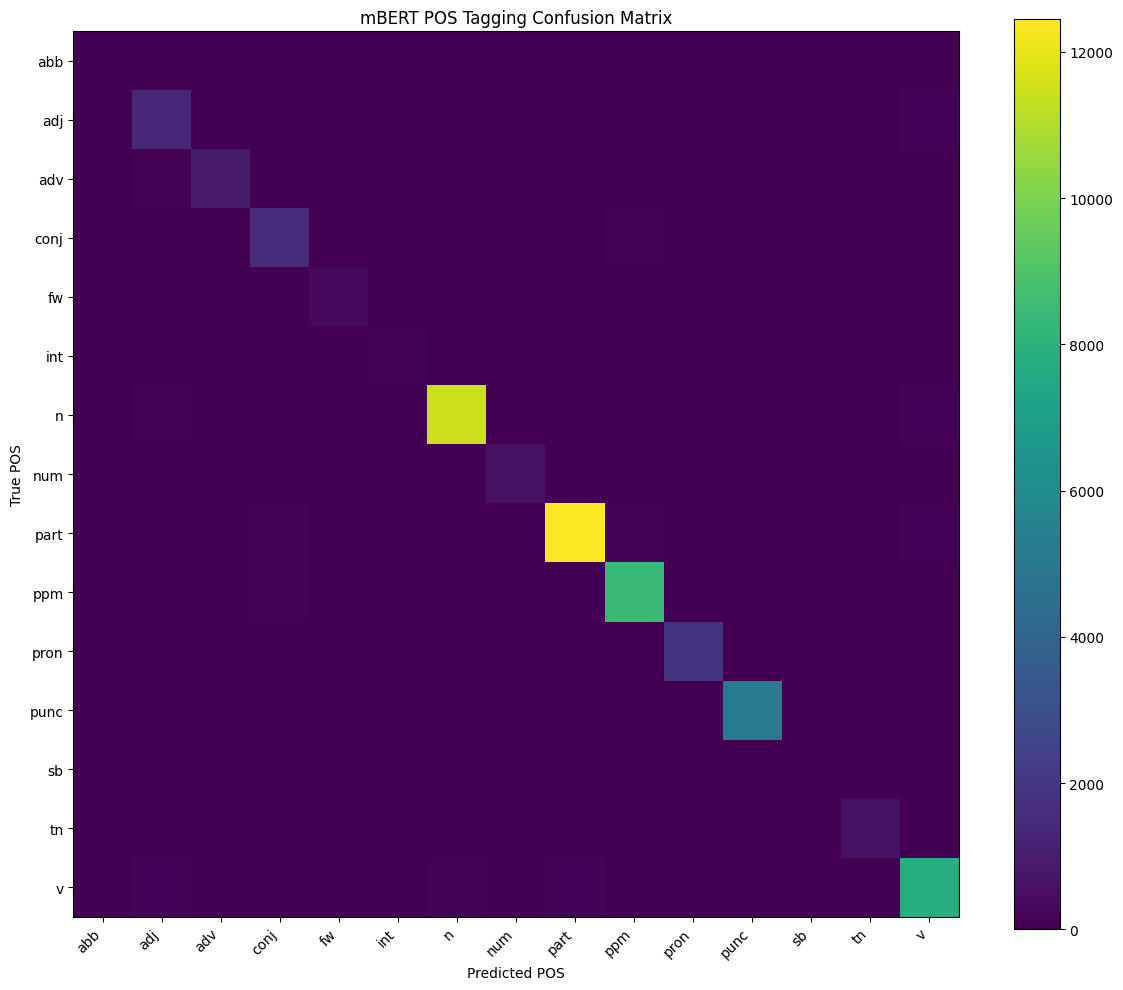

In [37]:
fig, ax = plt.subplots(
    figsize=(12, 10)
)

im = ax.imshow(cm)

ax.set_xticks(
    np.arange(len(pos_labels))
)

ax.set_yticks(
    np.arange(len(pos_labels))
)

ax.set_xticklabels(
    target_names,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    target_names
)

ax.set_xlabel(
    "Predicted POS"
)

ax.set_ylabel(
    "True POS"
)

ax.set_title(
    "mBERT POS Tagging Confusion Matrix"
)

fig.colorbar(im)

plt.tight_layout()
plt.show()

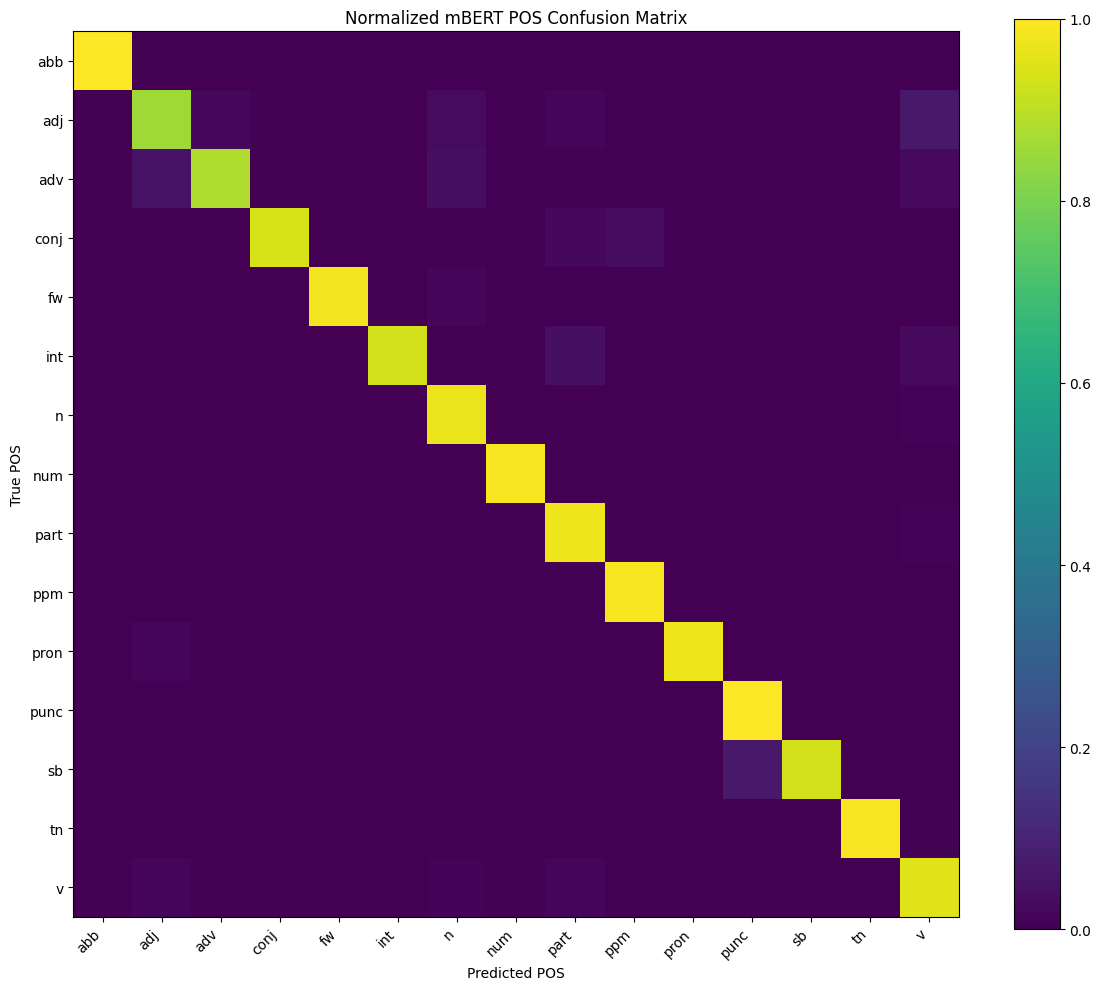

In [38]:
cm_normalized = confusion_matrix(
    y_true,
    y_pred,
    labels=label_ids,
    normalize="true"
)

fig, ax = plt.subplots(
    figsize=(12, 10)
)

im = ax.imshow(
    cm_normalized
)

ax.set_xticks(
    np.arange(len(pos_labels))
)

ax.set_yticks(
    np.arange(len(pos_labels))
)

ax.set_xticklabels(
    target_names,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    target_names
)

ax.set_xlabel(
    "Predicted POS"
)

ax.set_ylabel(
    "True POS"
)

ax.set_title(
    "Normalized mBERT POS Confusion Matrix"
)

fig.colorbar(im)

plt.tight_layout()
plt.show()

In [39]:
confusions = []

for true_id in range(len(pos_labels)):

    for pred_id in range(len(pos_labels)):

        if true_id == pred_id:
            continue

        count = cm[
            true_id,
            pred_id
        ]

        if count > 0:

            confusions.append({
                "true": id2label[true_id],
                "predicted": id2label[pred_id],
                "count": int(count)
            })


confusions = sorted(
    confusions,
    key=lambda x: x["count"],
    reverse=True
)


print("Top POS Confusions")
print("=" * 45)

for item in confusions[:15]:

    print(
        f"{item['true']:>8}"
        f" → "
        f"{item['predicted']:<8}"
        f" : {item['count']}"
    )

Top POS Confusions
       v → part     : 131
       v → adj      : 128
     adj → v        : 108
       n → v        : 105
    part → v        : 105
       v → n        : 92
    part → conj     : 90
       n → adj      : 88
    part → ppm      : 65
     ppm → conj     : 56
    conj → ppm      : 53
     adv → adj      : 50
     adj → n        : 44
       n → adv      : 43
    part → n        : 43


In [40]:
error_examples = []


for example_index, example in enumerate(test_data):

    encoding = tokenizer(
        example["tokens"],
        truncation=True,
        is_split_into_words=True,
        max_length=MAX_LENGTH
    )

    word_ids = encoding.word_ids()

    model_predictions = (
        predicted_labels[example_index]
    )

    model_true_labels = (
        true_labels[example_index]
    )

    previous_word_id = None

    for token_index, word_id in enumerate(
        word_ids
    ):

        if word_id is None:
            continue

        # Only evaluate first BERT piece
        if word_id == previous_word_id:
            continue

        if token_index >= len(model_true_labels):
            break

        true_id = model_true_labels[
            token_index
        ]

        pred_id = model_predictions[
            token_index
        ]

        if true_id != -100:

            true_tag = id2label[
                int(true_id)
            ]

            predicted_tag = id2label[
                int(pred_id)
            ]

            if true_tag != predicted_tag:

                error_examples.append({
                    "sentence_id":
                        example.get("id"),

                    "word":
                        example["tokens"][word_id],

                    "true":
                        true_tag,

                    "predicted":
                        predicted_tag,

                    "sentence":
                        example.get(
                            "text",
                            ""
                        )
                })

        previous_word_id = word_id

In [41]:
print(
    "Total POS errors:",
    len(error_examples)
)

Total POS errors: 1695


In [42]:
for i, error in enumerate(
    error_examples[:30],
    start=1
):

    print(f"\nError {i}")
    print(
        "Sentence ID:",
        error["sentence_id"]
    )

    print(
        "Word:",
        error["word"]
    )

    print(
        "True POS:",
        error["true"]
    )

    print(
        "Predicted POS:",
        error["predicted"]
    )

    print(
        "Sentence:",
        error["sentence"]
    )


Error 1
Sentence ID: sent_02835
Word: ကြီး
True POS: adj
Predicted POS: part
Sentence: သူကဒီအစည်းအဝေးကြီးရဲ့သဘာပတိပေါ့။ဒီနှစ်များအတောအတွင်းသူအတော်ပြောင်းလဲသွားတယ်။

Error 2
Sentence ID: sent_33949
Word: နဲ့
True POS: ppm
Predicted POS: conj
Sentence: အလုပ်ပြင်းပြင်းထန်ထန်မလုပ်ဘဲနဲ့အိပ်ရာထဲမှာရက်အနည်းငယ်လောက်နားလိုက်ပါ။

Error 3
Sentence ID: sent_08194
Word: လွန်း
True POS: adv
Predicted POS: part
Sentence: အလုပ်လုပ်တာပေါ့လျော့လွန်းတယ်။

Error 4
Sentence ID: sent_04827
Word: ပထမဆုံး
True POS: n
Predicted POS: adj
Sentence: လစဉ်ပထမဆုံးတနင်္ဂနွေနေ့မှာတက္ကသိုလ်တစ်နှစ်တည်းကျောင်းထွက်တွေတွေ့ဆုံပွဲရှိတယ်။

Error 5
Sentence ID: sent_16379
Word: တခြား
True POS: n
Predicted POS: adj
Sentence: ခင်ဗျားတို့ကတခြားကုမ္ပဏီရဲ့အမျိုးအစားတူကုန်ပစ္စည်းကိုကိုယ်စားလှယ်လုပ်နေသလား။

Error 6
Sentence ID: sent_16379
Word: တူ
True POS: adj
Predicted POS: v
Sentence: ခင်ဗျားတို့ကတခြားကုမ္ပဏီရဲ့အမျိုးအစားတူကုန်ပစ္စည်းကိုကိုယ်စားလှယ်လုပ်နေသလား။

Error 7
Sentence ID: sent_37649
Word: အမှန်
True POS: adv
Predicted P

In [43]:
from collections import Counter

error_word_counts = Counter(
    error["word"]
    for error in error_examples
)

print("Most frequently misclassified words")
print("=" * 45)

for word, count in error_word_counts.most_common(20):

    print(
        f"{word:<20} {count}"
    )

Most frequently misclassified words
နဲ့                  63
ပြီး                 60
ကောင်း               35
ရ                    31
နှင့်                27
နေ                   24
ဒီ                   24
ပေး                  24
ရာ                   17
ဟာ                   17
ကြီး                 15
အောင်                15
ထက်                  15
ထား                  14
ပြန်                 14
များ                 13
အားလုံး              12
တုန်း                12
တခြား                11
သွား                 11


In [44]:
error_type_counts = Counter(
    (
        error["true"],
        error["predicted"]
    )
    for error in error_examples
)

print("\nMost common error types")
print("=" * 45)

for (
    true_tag,
    predicted_tag
), count in error_type_counts.most_common(20):

    print(
        f"{true_tag:>8}"
        f" → "
        f"{predicted_tag:<8}"
        f" : {count}"
    )


Most common error types
       v → part     : 131
       v → adj      : 128
     adj → v        : 108
    part → v        : 105
       n → v        : 105
       v → n        : 92
    part → conj     : 90
       n → adj      : 88
    part → ppm      : 65
     ppm → conj     : 56
    conj → ppm      : 53
     adv → adj      : 50
     adj → n        : 44
    part → n        : 43
       n → adv      : 43
       n → part     : 42
     adv → n        : 41
     ppm → part     : 37
    conj → part     : 36
     adj → adv      : 33


In [45]:
ERROR_PATH = (
    f"{RESULTS_DIR}/pos_mbert_errors.json"
)

with open(
    ERROR_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        error_examples,
        f,
        ensure_ascii=False,
        indent=2
    )

print(
    "Error analysis saved:",
    ERROR_PATH
)

Error analysis saved: /content/drive/MyDrive/ShweMyanmar/results/pos_mbert_errors.json


In [46]:
FINAL_MODEL_DIR = (
    f"{MODEL_DIR}/pos_mbert_final"
)

trainer.save_model(
    FINAL_MODEL_DIR
)

tokenizer.save_pretrained(
    FINAL_MODEL_DIR
)

print(
    "Saved to:",
    FINAL_MODEL_DIR
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: /content/drive/MyDrive/ShweMyanmar/models/pos_mbert_final


In [47]:
with open(
    f"{FINAL_MODEL_DIR}/label2id.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        label2id,
        f,
        ensure_ascii=False,
        indent=2
    )


with open(
    f"{FINAL_MODEL_DIR}/id2label.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        id2label,
        f,
        ensure_ascii=False,
        indent=2
    )

In [48]:
print("Number of training examples:", len(tokenized_train))
print("Number of validation examples:", len(tokenized_val))
print("Number of test examples:", len(tokenized_test))

print("\nPOS Labels:")
print(label2id)

print("\nTest Results:")
print(test_results)

Number of training examples: 33641
Number of validation examples: 4205
Number of test examples: 4206

POS Labels:
{'abb': 0, 'adj': 1, 'adv': 2, 'conj': 3, 'fw': 4, 'int': 5, 'n': 6, 'num': 7, 'part': 8, 'ppm': 9, 'pron': 10, 'punc': 11, 'sb': 12, 'tn': 13, 'v': 14}

Test Results:
{'eval_loss': 0.1117905005812645, 'eval_accuracy': 0.9688138212728377, 'eval_precision': 0.9580144966819969, 'eval_recall': 0.9575190247922298, 'eval_f1': 0.9575553755322194, 'eval_weighted_f1': 0.9689234004542886}


In [49]:
RESULT_PATH = (
    f"{RESULTS_DIR}/pos_mbert_final_results.json"
)

result_data = {

    "experiment": "Standalone POS - mBERT",

    "model": MODEL_NAME,

    "dataset": "Shwe Myanmar dataset",

    "train_examples": len(train_data),

    "validation_examples": len(val_data),

    "test_examples": len(test_data),

    "num_pos_classes": len(pos_labels),

    "max_length": MAX_LENGTH,

    "learning_rate": 2e-5,

    "epochs": 3,

    "batch_size": 8,

    "test_results": {
        k: (
            float(v)
            if hasattr(v, "__float__")
            else v
        )
        for k, v in test_results.items()
    }
}


with open(
    RESULT_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        result_data,
        f,
        ensure_ascii=False,
        indent=2
    )


print(
    "Results saved:",
    RESULT_PATH
)

Results saved: /content/drive/MyDrive/ShweMyanmar/results/pos_mbert_final_results.json


In [50]:
from transformers import AutoTokenizer, AutoModelForTokenClassification

FINAL_MODEL_DIR = f"{MODEL_DIR}/pos"

test_tokenizer = AutoTokenizer.from_pretrained(
    FINAL_MODEL_DIR
)

test_model = AutoModelForTokenClassification.from_pretrained(
    FINAL_MODEL_DIR
)

print("Saved POS model loaded successfully!")
print("Number of labels:", test_model.config.num_labels)
print(test_model.config.id2label)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Saved POS model loaded successfully!
Number of labels: 14
{0: 'abb', 1: 'adj', 2: 'adv', 3: 'conj', 4: 'fw', 5: 'int', 6: 'n', 7: 'num', 8: 'part', 9: 'ppm', 10: 'pron', 11: 'punc', 12: 'tn', 13: 'v'}
